In [1]:
from pathlib import Path
from test import BOUTHESELInfo1

hesel_path = Path.cwd().resolve().parent / "simulatorer/BOUT/BOUT-HESEL"
data_folder = "data"

info1 = BOUTHESELInfo1(hesel_path, data_folder)

In [2]:
data0 = info1._load_data(0)
data1 = info1._load_data(1)
data2 = info1._load_data(2)
data3 = info1._load_data(3)


In [ ]:
for k, v in info1.data.items():lnn (26, 34, 128)
lnpe (26, 34, 128)
lnpi (26, 34, 128)
vort (26, 34, 128)
phi (26, 34, 128)
print(k, v.shape)

lnn (26, 34, 128)
lnpe (26, 34, 128)
lnpi (26, 34, 128)
vort (26, 34, 128)
phi (26, 34, 128)
init_n (34,)
init_pe (34,)
init_pi (34,)
sigma_open (34,)
sigma_closed (34,)
sigma_force (34,)
B (34,)
t_array (26,)


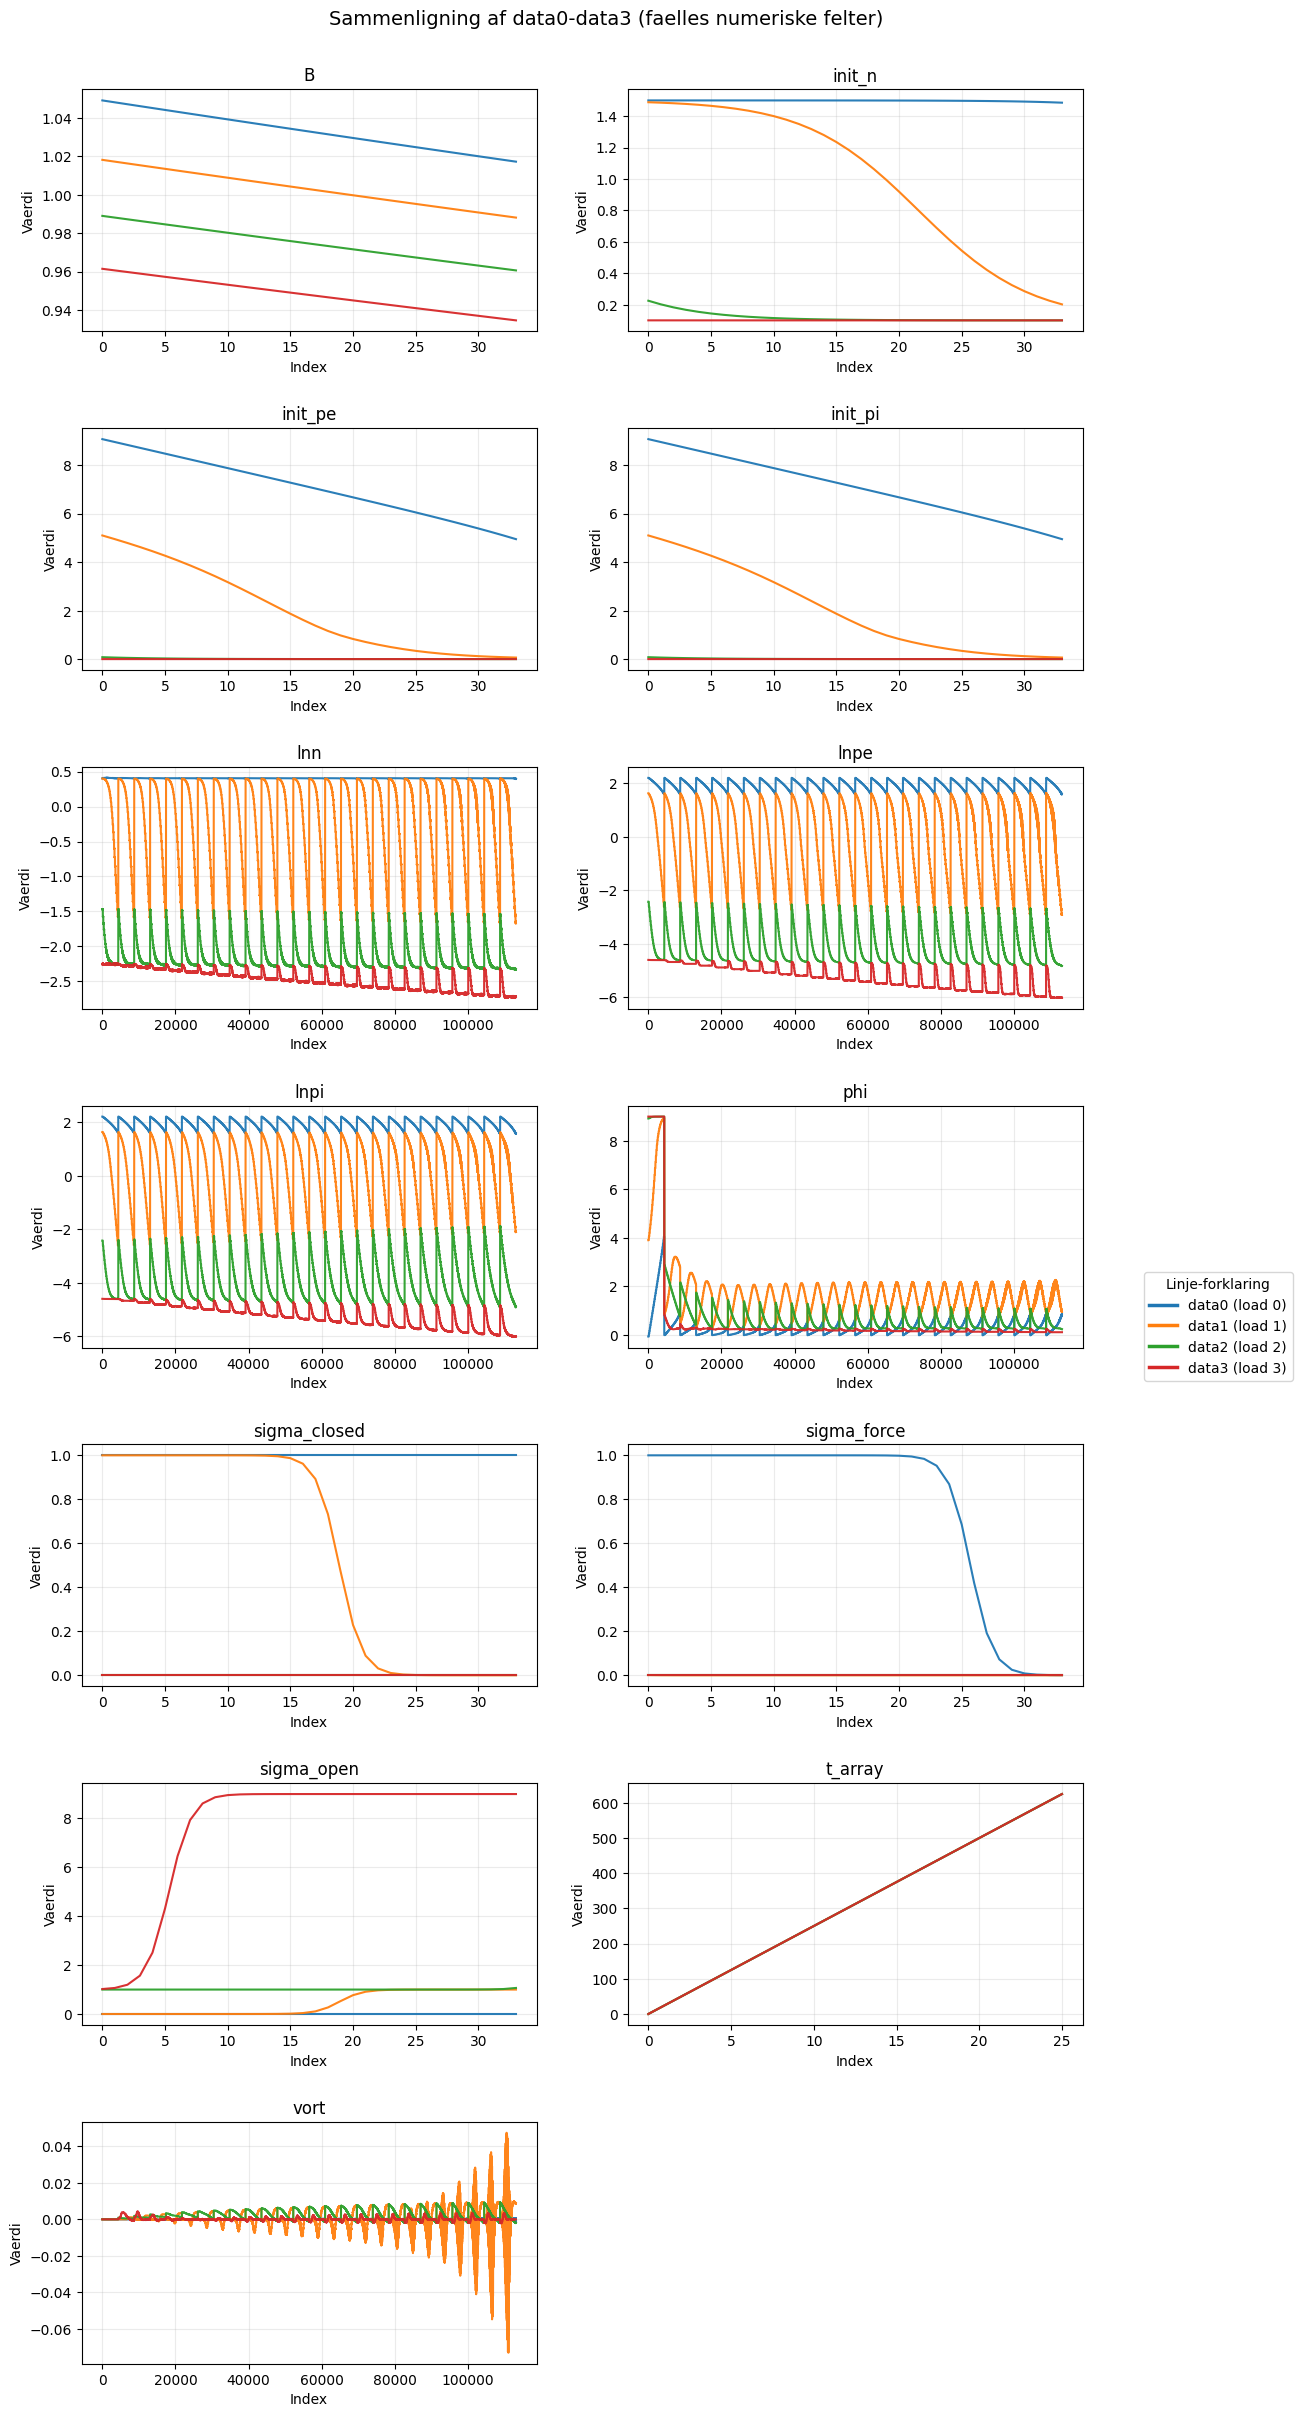

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _to_numeric_1d(value):
    if np.isscalar(value):
        return np.array([float(value)], dtype=float)

    arr = np.asarray(value)
    if arr.dtype.kind in "biufc":
        return np.ravel(np.real(arr)).astype(float)

    return None


datasets = {
    "data0": data0,
    "data1": data1,
    "data2": data2,
    "data3": data3,
}

styles = {
    "data0": {"color": "tab:blue", "label": "data0 (load 0)"},
    "data1": {"color": "tab:orange", "label": "data1 (load 1)"},
    "data2": {"color": "tab:green", "label": "data2 (load 2)"},
    "data3": {"color": "tab:red", "label": "data3 (load 3)"},
}

common_keys = set.intersection(*(set(d.keys()) for d in datasets.values()))
plot_data = []

for key in sorted(common_keys):
    series = {}
    key_is_numeric = True

    for name in datasets:
        arr = _to_numeric_1d(datasets[name][key])
        if arr is None:
            key_is_numeric = False
            break
        series[name] = arr

    if key_is_numeric:
        plot_data.append((key, series))

if not plot_data:
    print("Ingen faelles numeriske noegler fundet i data0-data3.")
else:
    nplots = len(plot_data)
    ncols = 2
    nrows = (nplots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (key, series) in zip(axes, plot_data):
        min_len = min(len(arr) for arr in series.values())
        x = np.arange(min_len)

        for name in datasets:
            arr = series[name]
            ax.plot(
                x,
                arr[:min_len],
                linewidth=1.5,
                alpha=0.95,
                color=styles[name]["color"],
                label=styles[name]["label"],
            )

        ax.set_title(str(key), fontsize=12, pad=6)
        ax.set_xlabel("Index")
        ax.set_ylabel("Vaerdi")
        ax.grid(alpha=0.25)

    for ax in axes[nplots:]:
        ax.axis("off")

    legend_handles = [
        Line2D([0], [0], color=styles[name]["color"], lw=2.5, label=styles[name]["label"])
        for name in datasets
    ]

    fig.legend(
        handles=legend_handles,
        loc="center right",
        bbox_to_anchor=(0.995, 0.5),
        title="Linje-forklaring",
        frameon=True,
    )

    fig.suptitle("Sammenligning af data0-data3 (faelles numeriske felter)", fontsize=14, y=0.995)
    fig.subplots_adjust(top=0.965, right=0.84, hspace=0.4)
    plt.show()

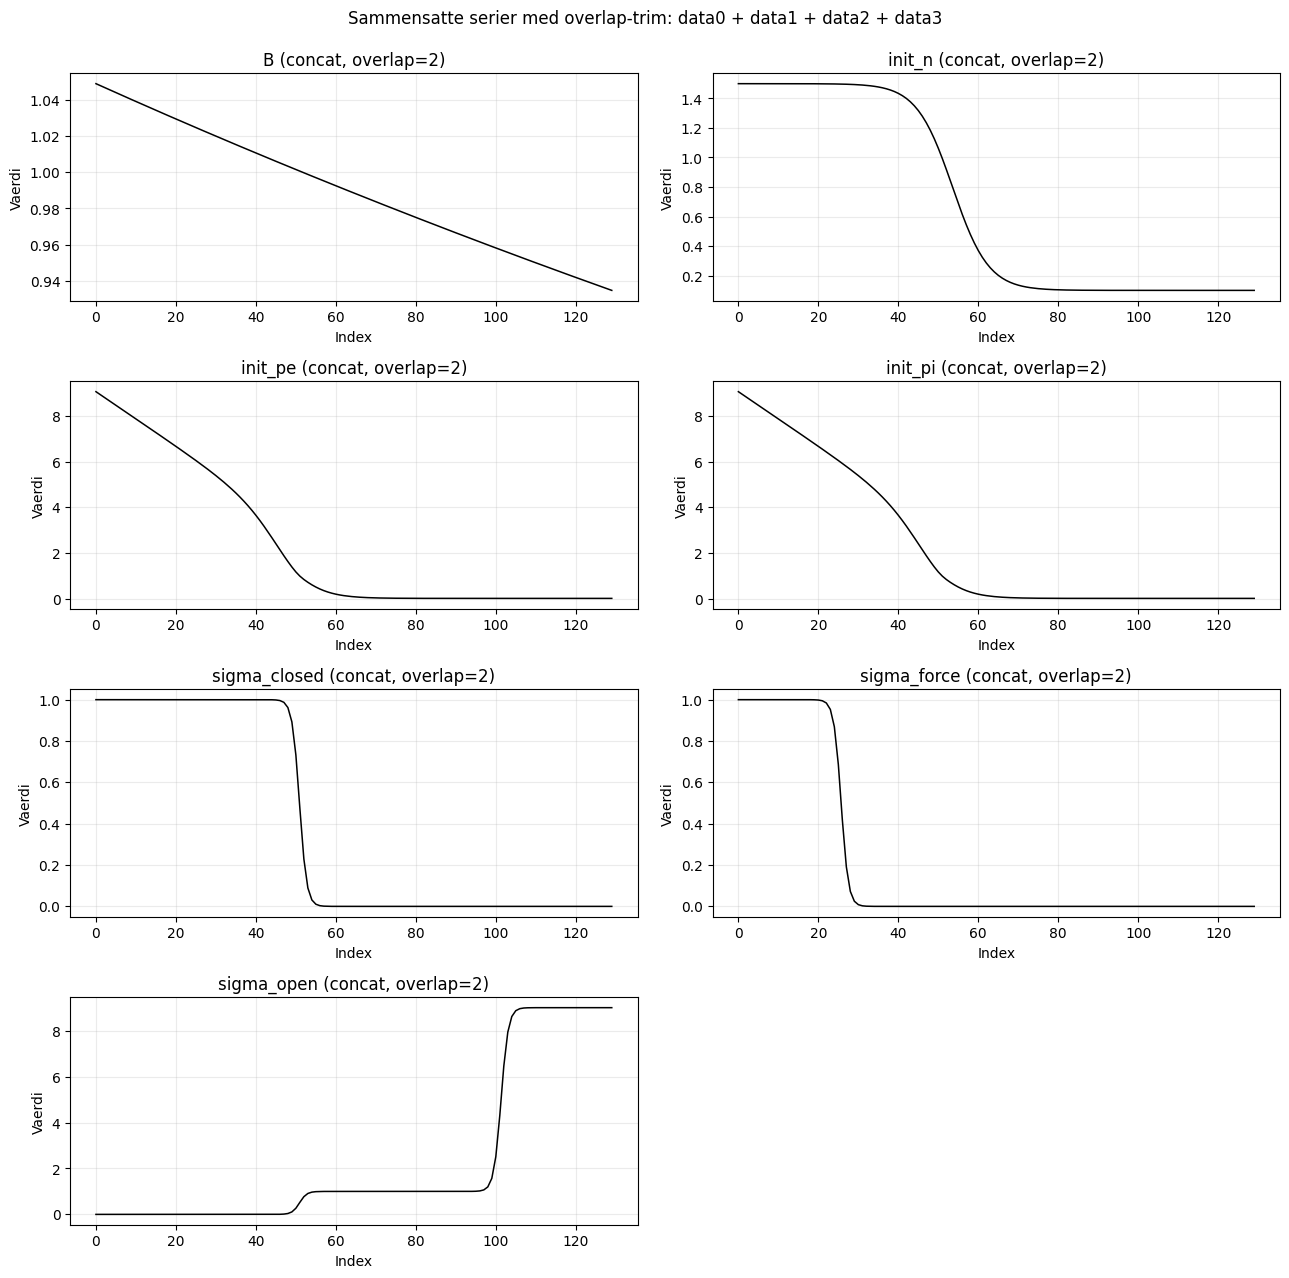

In [7]:
# Konkatener udvalgte felter paa tvaers af data0 -> data3
# overlap_points = antal punkter, der fjernes i starten af hvert efterfoelgende array
# for at undgaa hak i samlingen (typisk 1-2).
overlap_points = 2

keys_to_concat = [
    "B",
    "init_n",
    "init_pe",
    "init_pi",
    "sigma_closed",
    "sigma_force",
    "sigma_open",
]

source_order = [data0, data1, data2, data3]
source_names = ["data0", "data1", "data2", "data3"]


def concat_with_overlap(parts, overlap=0):
    if overlap <= 0:
        return np.concatenate(parts, axis=0)

    stitched = [parts[0]]
    for part in parts[1:]:
        if len(part) <= overlap:
            raise ValueError(
                f"Overlap ({overlap}) er stoerre end eller lig med laengden af et del-array ({len(part)})."
            )
        stitched.append(part[overlap:])

    return np.concatenate(stitched, axis=0)


concat_data = {}

for key in keys_to_concat:
    parts = []
    for src in source_order:
        if key not in src:
            raise KeyError(f"Noeglen '{key}' findes ikke i et af datasaettende.")
        parts.append(np.ravel(np.asarray(src[key])))

    concat_data[key] = concat_with_overlap(parts, overlap=overlap_points)

# Vis status foer/efter overlap-trim
for key in keys_to_concat:
    lengths_raw = [len(np.ravel(np.asarray(src[key]))) for src in source_order]
    raw_total = sum(lengths_raw)
    overlap_removed = overlap_points * (len(source_order) - 1)
    final_total = len(concat_data[key])


# Optional: hurtig visualisering af de sammensatte serier
ncols = 2
nrows = (len(keys_to_concat) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, key in zip(axes, keys_to_concat):
    y = concat_data[key]
    ax.plot(y, color="black", linewidth=1.1)
    ax.set_title(f"{key} (concat, overlap={overlap_points})")
    ax.set_xlabel("Index")
    ax.set_ylabel("Vaerdi")
    ax.grid(alpha=0.25)

for ax in axes[len(keys_to_concat):]:
    ax.axis("off")

fig.suptitle("Sammensatte serier med overlap-trim: data0 + data1 + data2 + data3", y=0.995)
fig.tight_layout()
plt.show()